### Imports

In [1]:
import numpy as np
import polars as pl
import pod5
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
problematic_3mers = set(['AAA', 'AAG', 'AAT', 'AGA', 'AGG', 'TTT', 'CAG', 'CTT', 'CCC', 'CGG', 'GAG', 'GGA', 'GGG'])
#problematic_3mers = set(['AAA', 'TTT'])
POD5 = '/mnt/sod2-project/csb4/wgs/metagenomics_data/projects/segmentation/segmentation_data/R10_Zymo_subsample/barcode24_zymo_wo_EC_1k_per_species_min_len_1k/barcode24_zymo_subsampled_wo_EC_min_len_1k.pod5'
ALIGNMENTS = '/home/stumaxime/scratch/Campolina/alignments_unet_4L_old_labels_reduced_lr.csv'

### Model

(copied from repo)

In [3]:
import torch
from torch import nn, Tensor
from torch.utils import checkpoint

# constants
INPUT_CHANNELS = 4 # n features
KERNEL = 3 # kernel size of encoder and decoder layers
KERNEL_FIRST = 9 # size of kernel of first layer
KERNEL_BOTTLENECK = 5 # size of kernel at bottleneck

class UNet(nn.Module):

    def __init__(
            self,
            channels: list[int],
            checkpoint: bool = False,
        ):

        super().__init__()

        rchannels = list(reversed(channels))

        self.first = ConvBlock(
            INPUT_CHANNELS, 
            channels[0], 
            KERNEL_FIRST,
        )

        self.downlayers = nn.ModuleList([
            Down(in_ch=in_ch, out_ch=out_ch, kernel=KERNEL)
            for (in_ch, out_ch) in zip(channels[:-1], channels[1:])
        ])

        self.middle = ConvBlock(channels[-1], channels[-1], KERNEL_BOTTLENECK)

        self.uplayers = nn.ModuleList([
            Up(in_ch=in_ch*2, out_ch=out_ch, kernel=KERNEL, checkpoint=checkpoint)
            for (in_ch, out_ch) in zip(rchannels[:-1], rchannels[1:])
        ])

        self.last = nn.Conv1d(channels[0]*2, 1, kernel_size=1)

    @classmethod
    def make_default(cls, checkpoint = False):
        return cls(
            channels=[64, 128, 128, 128, 256], 
            checkpoint=checkpoint,
        )

    def downsample(self, tensor: Tensor) -> tuple[Tensor, list]:
        '''Apply the layers in `self.downlayers` and track residuals.'''

        residuals = []
        for down in self.downlayers:
            tensor = down(tensor)
            residual = tensor
            residuals.append(residual)

        return tensor, residuals

    def upsample(self, tensor: Tensor, residuals: list[Tensor]) -> Tensor:
        '''Apply the layers in `self.uplayers` with concatenated residuals.'''

        for i, up in enumerate(self.uplayers):
            residual = residuals[-(i+1)]
            tensor = torch.concat([tensor, residual], dim=1)
            tensor = up(tensor)

        return tensor

    def forward(self, tensor: Tensor) -> Tensor:
        # first layer 
        first_out = self.first(tensor)

        # downsample
        downsample_out, residuals = self.downsample(first_out)

        # bottleneck
        middle_out = self.middle(downsample_out)

        # upsample
        upsample_out = self.upsample(middle_out, residuals)

        # last
        input_last = torch.concat([upsample_out, first_out], dim=1)
        final_out = self.last(input_last).squeeze(1)

        return final_out

class Down(nn.Module):
    '''Halves the input by applying DoubleConv + Pooling.'''

    def __init__(self, in_ch: int, out_ch: int, kernel: int):
        super().__init__()
        self.layers = nn.Sequential(DoubleConvBlock(in_ch, out_ch, kernel), nn.MaxPool1d(2, 2))

    def forward(self, tensor: Tensor) -> Tensor: return self.layers(tensor)

class Up(nn.Module):
    '''Upsample the input using Nearest Upsampling + DoubleConv.'''

    def __init__(self, in_ch: int, out_ch: int, kernel: int, checkpoint: bool):
        super().__init__()
        assert kernel % 2 == 1
        self.ckpt = checkpoint
        self.layers = nn.Sequential(nn.Upsample(scale_factor=2, mode='nearest'), DoubleConvBlock(in_ch, out_ch, kernel))

    def forward(self, tensor: Tensor) -> Tensor:
        if not self.ckpt: return self.layers(tensor)
        return checkpoint.checkpoint(lambda _: self.layers(_), tensor, use_reentrant=False)

class DoubleConvBlock(nn.Module):
    '''Apply two 1d convolutions in a row, with mid_channels = max(in_channels, out_channels).'''

    def __init__(self, in_ch: int, out_ch: int, kernel: int):
        super().__init__()
        mid_ch = max(in_ch, out_ch)
        self.proj = nn.Identity() if in_ch == out_ch else nn.Conv1d(in_ch, out_ch, 1)
        self.layers = nn.Sequential(ConvBlock(in_ch, mid_ch, kernel), ConvBlock(mid_ch, out_ch, kernel))

    def forward(self, tensor: Tensor) -> Tensor: return self.layers(tensor) + self.proj(tensor)

class ConvBlock(nn.Module):
    '''Convolution + BatchNorm + GELU'''

    def __init__(self, in_ch: int, out_ch: int, kernel: int):
        assert kernel % 2 == 1

        super().__init__()
        padding = (kernel - 1) // 2 # pad to same size

        self.block = nn.Sequential(
            nn.Conv1d(
                in_channels=in_ch, 
                out_channels=out_ch,
                kernel_size=kernel,
                padding=padding,
            ),
            nn.BatchNorm1d(num_features=out_ch),
            nn.GELU(),
        )

    def forward(self, tensor: Tensor) -> Tensor: return self.block(tensor)

### Remove columns we won't use

In [4]:
todrop = [
    'event_start',
    'event_end',
    'event_mean',
    #'event_align_status',
    'nearest_table_kmer',
    #'remora_event_mean',
    'ref_kmer_level',
]

alignments = (
    pl.read_csv(ALIGNMENTS)
    .drop(todrop) # remove columns corresponding to predictions
    .unique(['read_id', 'remora_start']) # remove duplicates (insertion errors)
    .sort(['read_id', 'remora_start']) # sort by indices
    .with_row_index() # add row idx for later
)

print(alignments.head(3))

shape: (3, 7)
┌───────┬──────────────┬────────────┬────────────────┬───────────┬────────────────┬────────────────┐
│ index ┆ remora_start ┆ remora_end ┆ remora_event_m ┆ ref_kmer  ┆ event_align_st ┆ read_id        │
│ ---   ┆ ---          ┆ ---        ┆ ean            ┆ ---       ┆ atus           ┆ ---            │
│ u32   ┆ i64          ┆ i64        ┆ ---            ┆ str       ┆ ---            ┆ str            │
│       ┆              ┆            ┆ f64            ┆           ┆ i64            ┆                │
╞═══════╪══════════════╪════════════╪════════════════╪═══════════╪════════════════╪════════════════╡
│ 0     ┆ 1348         ┆ 1352       ┆ 1.6734296      ┆ TGGACCTGC ┆ 0              ┆ 0004af8b-485c- │
│       ┆              ┆            ┆                ┆           ┆                ┆ 4800-8cf2-d1e5 │
│       ┆              ┆            ┆                ┆           ┆                ┆ 8c…            │
│ 1     ┆ 1352         ┆ 1358       ┆ 0.9025967      ┆ GGACCTGCG ┆ 0         

### Add problematic kmers columns

In [5]:
alignments = alignments.with_columns((pl.col('ref_kmer').str.to_uppercase()))
alignments = alignments.with_columns((pl.col('ref_kmer').str.slice(5, 3).is_in(problematic_3mers)).alias('pb'))
alignments.write_csv('alignments.csv')
print(alignments.head(2))

shape: (2, 8)
┌───────┬──────────────┬────────────┬──────────────┬───────────┬─────────────┬─────────────┬───────┐
│ index ┆ remora_start ┆ remora_end ┆ remora_event ┆ ref_kmer  ┆ event_align ┆ read_id     ┆ pb    │
│ ---   ┆ ---          ┆ ---        ┆ _mean        ┆ ---       ┆ _status     ┆ ---         ┆ ---   │
│ u32   ┆ i64          ┆ i64        ┆ ---          ┆ str       ┆ ---         ┆ str         ┆ bool  │
│       ┆              ┆            ┆ f64          ┆           ┆ i64         ┆             ┆       │
╞═══════╪══════════════╪════════════╪══════════════╪═══════════╪═════════════╪═════════════╪═══════╡
│ 0     ┆ 1348         ┆ 1352       ┆ 1.6734296    ┆ TGGACCTGC ┆ 0           ┆ 0004af8b-48 ┆ false │
│       ┆              ┆            ┆              ┆           ┆             ┆ 5c-4800-8cf ┆       │
│       ┆              ┆            ┆              ┆           ┆             ┆ 2-d1e58c…   ┆       │
│ 1     ┆ 1352         ┆ 1358       ┆ 0.9025967    ┆ GGACCTGCG ┆ 0           

### Load preprocessed df

In [6]:
alignments = pl.read_csv('alignments.csv')
print(alignments.head(1))

shape: (1, 8)
┌───────┬──────────────┬────────────┬──────────────┬───────────┬─────────────┬─────────────┬───────┐
│ index ┆ remora_start ┆ remora_end ┆ remora_event ┆ ref_kmer  ┆ event_align ┆ read_id     ┆ pb    │
│ ---   ┆ ---          ┆ ---        ┆ _mean        ┆ ---       ┆ _status     ┆ ---         ┆ ---   │
│ i64   ┆ i64          ┆ i64        ┆ ---          ┆ str       ┆ ---         ┆ str         ┆ bool  │
│       ┆              ┆            ┆ f64          ┆           ┆ i64         ┆             ┆       │
╞═══════╪══════════════╪════════════╪══════════════╪═══════════╪═════════════╪═════════════╪═══════╡
│ 0     ┆ 1348         ┆ 1352       ┆ 1.6734296    ┆ TGGACCTGC ┆ 0           ┆ 0004af8b-48 ┆ false │
│       ┆              ┆            ┆              ┆           ┆             ┆ 5c-4800-8cf ┆       │
│       ┆              ┆            ┆              ┆           ┆             ┆ 2-d1e58c…   ┆       │
└───────┴──────────────┴────────────┴──────────────┴───────────┴─────────────

### Errors analysis

In [9]:
pb = alignments.filter((pl.col('pb') == True))
err = alignments.filter(pl.col('event_align_status') != 0)
pb_and_err = pb.filter(pl.col('event_align_status') != 0)
#print(pb.height, err.height, pb.height+err.height, pb_and_err.height)

print(f'P(error) = {(err.height / alignments.height)*100:.0f}%.')
print(f'P(problematic kmer) = {(pb.height / alignments.height)*100:.0f}%.\n')
print(f'P(problematic | error) = {(pb_and_err.height / err.height)*100:.0f}%.')
print(f'P(error | problematic) = {(pb_and_err.height / pb.height)*100:.0f}%.')

P(error) = 28%.
P(problematic kmer) = 23%.

P(problematic | error) = 38%.
P(error | problematic) = 47%.


### Compute rolling window of number of problematic kmers and errors

In [10]:
window = 1000

alignments = alignments.with_columns([
    (
        pl.col('pb')
        .cast(pl.Int8)
        .rolling_sum(window_size=window, center=True)
        .over(pl.col('read_id'))
        .alias('n_pbs_window')
    ),
    (
        (pl.col('event_align_status') != 0)
        .cast(pl.Int8)
        .rolling_sum(window_size=window, center=True)
        .over(pl.col('read_id'))
        .alias('n_errors_window')
    )
])

print(f'{alignments.filter(pl.col('n_errors_window').is_null()).height / alignments.height:.2f}')

0.14


### Correlation between problematic kmers and errors

In [11]:
alignments = alignments.filter(pl.col('n_errors_window').is_not_null())
alignments[['n_pbs_window', 'n_errors_window']].corr()

n_pbs_window,n_errors_window
f64,f64
1.0,0.318387
0.318387,1.0


### Distributions

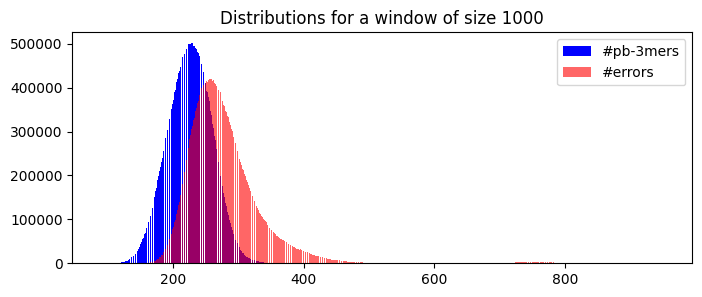

In [12]:
plt.figure(figsize=(8, 3))
plt.bar(*alignments['n_pbs_window'].value_counts(), color='blue', label='#pb-3mers')
plt.bar(*alignments['n_errors_window'].value_counts(), color='red', label='#errors', alpha=0.6)
plt.legend()
plt.title(f'Distributions for a window of size {window}')
plt.show()

### Getting the input signal

In [13]:
def get_signal(read_id):
    with pod5.Reader(POD5) as reader:
        read = next(reader.reads(selection=[read_id]))
        signal = read.signal    
    return signal

(108320, 'db8b3837-cb54-4fd2-b227-b42dd3d168e2')

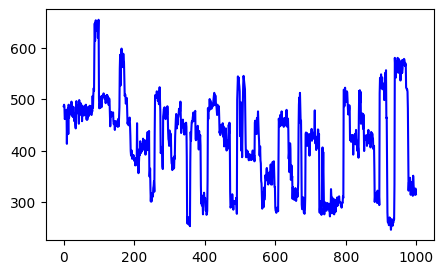

In [14]:
plt.figure(figsize=(5, 3))
rids = alignments['read_id'].unique()

rid = rids[np.random.randint(low=0, high=len(rids))]
signal = get_signal(rid)
signal = signal[:-(len(signal) % 16)]

plt.plot(signal[:1000], color='blue')
len(signal), rid

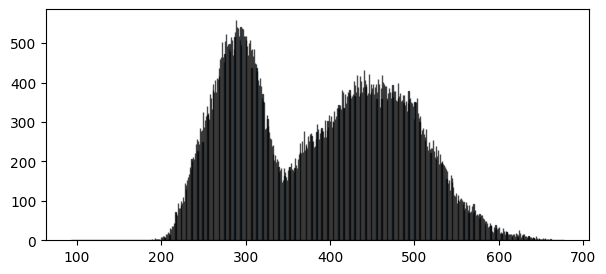

In [15]:
from scipy import stats

bins = 5000

counts, edges = np.histogram(signal, bins=bins)

centers = (edges[:-1] + edges[1:]) / 2
plt.figure(figsize=(7, 3))
plt.bar(centers, counts, width=np.diff(edges), edgecolor="black", alpha=0.7)
plt.show()

Note: looks a lot like a 2-variate gaussian, thats probably why the hmm model worked quite well ?

### Loading model

In [16]:
state_dict = {
    k.replace('_orig_mod.', ''): v 
    for k, v in torch.load('unet.pth', weights_only=True, map_location=torch.device('cpu')).items()
}

model = UNet.make_default()
model.load_state_dict(state_dict)

<All keys matched successfully>

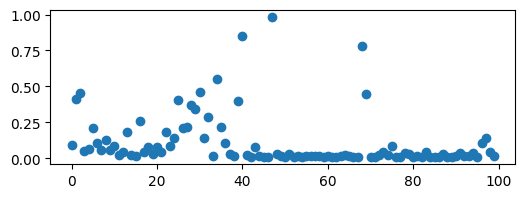

In [17]:
def make_input(signal):
    signal = stats.zscore(signal)
    diff1 = np.diff(signal, prepend=0)
    windows = np.lib.stride_tricks.sliding_window_view(signal, 3)
    means = np.pad(windows.mean(axis=1), (1, 1))
    stds = np.pad(windows.std(axis=1), (1, 1))
    return torch.tensor(np.stack([signal, diff1, means, stds]), dtype=torch.float32)

input = make_input(signal).unsqueeze(0)
#preds = model(input).detach().numpy().squeeze()
preds = model(input).sigmoid().detach().numpy().squeeze()

plt.figure(figsize=(6, 2))
plt.scatter(np.arange(100), preds[2000:2100])

In [18]:
def get_labels(signal):
    labels = np.zeros_like(signal)
    for row in alignments.filter(pl.col('read_id') == rid).iter_rows():
        labels[row[1]] = 1
        labels[row[2]] = 1
    return labels

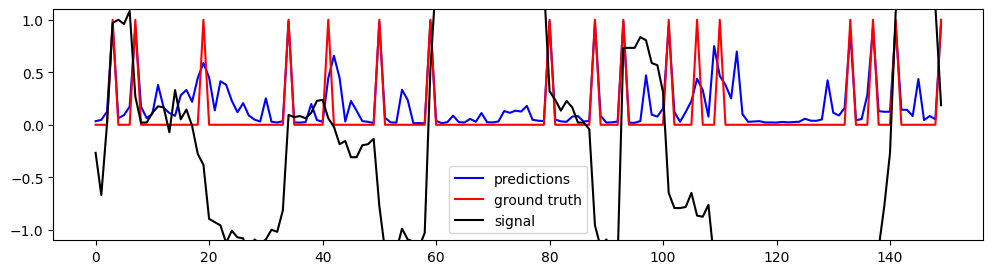

In [19]:
labels = get_labels(signal)

base = len(signal) // 2
L = 150

plt.figure(figsize=(12, 3))
plt.plot(preds[base:base+L], color='blue', label='predictions')
plt.plot(labels[base:base+L], color='red', label='ground truth')
plt.plot(stats.zscore(signal)[base:base+L], color='black', label='signal')
plt.ylim(-1.1, 1.1)
plt.legend()
plt.show()

### Getting kmers that lead to many deletion errors

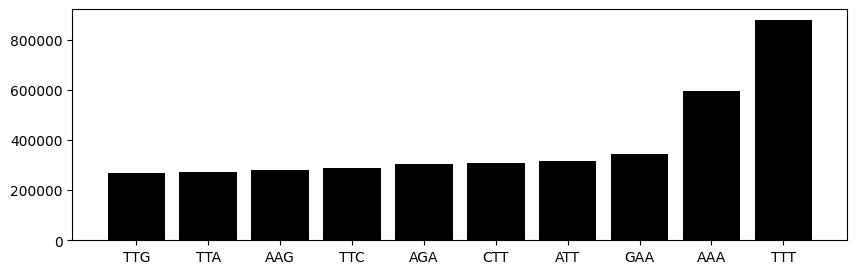

In [20]:
DELETION = 1

deletions = alignments.filter(pl.col('event_align_status') == DELETION)
deletions = deletions.with_columns(pl.col('ref_kmer').str.slice(5, 3))
kmers_deletions = deletions['ref_kmer']

counts = kmers_deletions.value_counts()
counts = counts.filter(pl.col('count') > counts['count'].mean() + counts['count'].std()).sort('count')

plt.figure(figsize=(10, 3))
plt.bar(*counts, color='black')
plt.show()

In [21]:
for kmer in ['AAA', 'TTT']:
    df = alignments.filter(pl.col('ref_kmer').str.slice(5, 3) == kmer)
    p = df.filter(pl.col('event_align_status') == DELETION).height / df.height
    print(f'P({kmer} is deletion error | kmer is {kmer}) = {p*100:.0f}%')
    p = df.filter(pl.col('event_align_status') == DELETION).height / alignments.filter(pl.col('event_align_status') == DELETION).height
    print(f'P(kmer is {kmer} | deletion error) = {p*100:.0f}%\n')

P(AAA is deletion error | kmer is AAA) = 39%
P(kmer is AAA | deletion error) = 7%

P(TTT is deletion error | kmer is TTT) = 58%
P(kmer is TTT | deletion error) = 10%



### Visualizing signal in regions with many errors

In [22]:
# mean + 3std ~= the 1% largest values
many_errors = alignments.filter(pl.col('n_errors_window') > pl.col('n_errors_window').mean() + 3*pl.col('n_errors_window').std())
#many_errors = alignments.filter(pl.col('n_errors_window') > 99)
print(many_errors.head(2))
print(many_errors.height / alignments.height)

shape: (2, 10)
┌────────┬────────────┬────────────┬────────────┬───┬────────────┬───────┬────────────┬────────────┐
│ index  ┆ remora_sta ┆ remora_end ┆ remora_eve ┆ … ┆ read_id    ┆ pb    ┆ n_pbs_wind ┆ n_errors_w │
│ ---    ┆ rt         ┆ ---        ┆ nt_mean    ┆   ┆ ---        ┆ ---   ┆ ow         ┆ indow      │
│ i64    ┆ ---        ┆ i64        ┆ ---        ┆   ┆ str        ┆ bool  ┆ ---        ┆ ---        │
│        ┆ i64        ┆            ┆ f64        ┆   ┆            ┆       ┆ i64        ┆ i64        │
╞════════╪════════════╪════════════╪════════════╪═══╪════════════╪═══════╪════════════╪════════════╡
│ 478870 ┆ 26557      ┆ 26562      ┆ -0.043223  ┆ … ┆ 0257b036-9 ┆ false ┆ 213        ┆ 461        │
│        ┆            ┆            ┆            ┆   ┆ 43d-4bac-8 ┆       ┆            ┆            │
│        ┆            ┆            ┆            ┆   ┆ fd3-8df06e ┆       ┆            ┆            │
│        ┆            ┆            ┆            ┆   ┆ …          ┆       ┆  

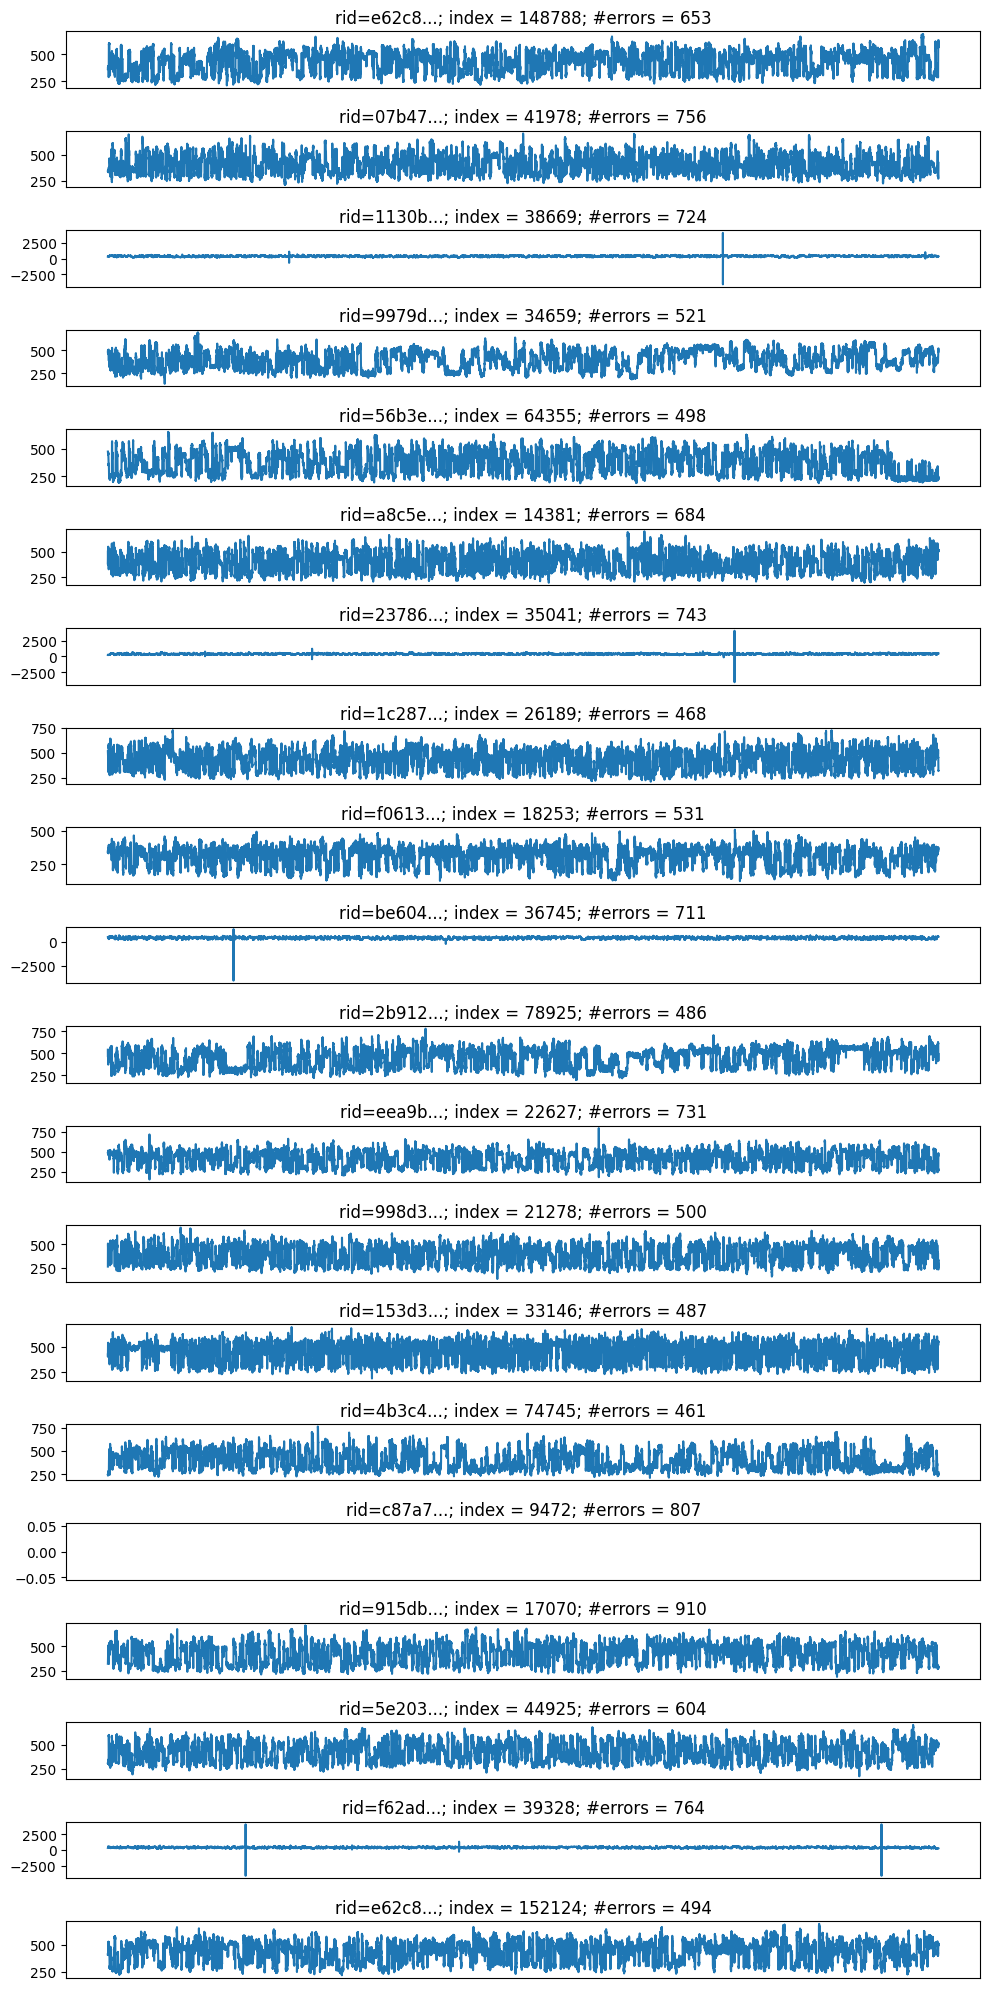

In [23]:
n = 20

err_rows = many_errors.sample(n=n)
fig, ax = plt.subplots(n, figsize=(10, 20))

for i, row in enumerate(err_rows.iter_rows(named=True)):
    rid = row['read_id']
    errors = row['n_errors_window']
    idx = (row['remora_start'] + row['remora_end']) // 2
    signal = get_signal(rid)
    ax[i].plot(signal[idx-10_000:idx+10_000])
    ax[i].set_title(f'rid={rid[:5]}...; index = {idx}; #errors = {errors}')
    ax[i].set_xticks([])

plt.tight_layout()
plt.show()